In [ ]:
# ============================================
# STEP 1: Import required libraries
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# For reproducibility
np.random.seed(42)


# ============================================
# STEP 2: Define the overdamped model
# y(t) = A * exp(-k*t) + C
# ============================================
def overdamped_model(t, A, k, C):
    return A * np.exp(-k * t) + C


# ============================================
# STEP 3: Generate synthetic (random) test data
# ============================================

# True parameters (unknown in real case)
A_true = 5.0
k_true = 1.2
C_true = 0.8

# Generate time values
t_data = np.linspace(0, 5, 100)

# Generate clean signal
y_clean = overdamped_model(t_data, A_true, k_true, C_true)

# Add Gaussian noise
noise = np.random.normal(0, 0.3, size=t_data.shape)
y_noisy = y_clean + noise


# ============================================
# STEP 4: Fit the model to noisy data
# ============================================

# Initial guess for parameters
initial_guess = [4, 1, 0]

# Curve fitting
params_opt, params_cov = curve_fit(overdamped_model, t_data, y_noisy, p0=initial_guess)

A_fit, k_fit, C_fit = params_opt

print("Fitted Parameters:")
print(f"A = {A_fit:.4f}")
print(f"k = {k_fit:.4f}")
print(f"C = {C_fit:.4f}")


# ============================================
# STEP 5: Generate fitted curve
# ============================================

y_fit = overdamped_model(t_data, A_fit, k_fit, C_fit)


# ============================================
# STEP 6: Evaluate Model Performance
# ============================================

mse = mean_squared_error(y_noisy, y_fit)
rmse = np.sqrt(mse)
r2 = r2_score(y_noisy, y_fit)

print("\nModel Evaluation Metrics:")
print(f"MSE  = {mse:.6f}")
print(f"RMSE = {rmse:.6f}")
print(f"R^2  = {r2:.6f}")


# ============================================
# STEP 7: Plot Data and Fitted Curve
# ============================================

plt.figure(figsize=(8, 5))

plt.scatter(t_data, y_noisy, label="Noisy Data", color="blue", alpha=0.6)
plt.plot(t_data, y_fit, label="Fitted Model", color="red", linewidth=2)
plt.plot(t_data, y_clean, '--', label="True Curve", color="green")

plt.title("Overdamped Exponential Fit")
plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
np.random.seed(42)


# ============================================
# STEP 2: Define Models
# ============================================

# Critical damping model
def critical_model(t, A, B, w):
    return (A + B*t) * np.exp(-w*t)

# Overdamped model
def overdamped_model(t, A, B, w, zeta):
    r1 = -w * (zeta + np.sqrt(zeta**2 - 1))
    r2 = -w * (zeta - np.sqrt(zeta**2 - 1))
    return A * np.exp(r1*t) + B * np.exp(r2*t)


# ============================================
# STEP 3: Generate Time Data
# ============================================
t = np.linspace(0, 5, 200)


# ============================================
# STEP 4: Generate 3 Different Datasets
# ============================================

# --- Critical Damping (zeta = 1)
A1, B1, w1 = 3, -2, 2
y_critical_clean = critical_model(t, A1, B1, w1)
y_critical = y_critical_clean + np.random.normal(0, 0.05, size=t.shape)

# --- Slightly Overdamped (zeta = 1.5)
A2, B2, w2, z2 = 2, 1, 2, 1.5
y_over_clean = overdamped_model(t, A2, B2, w2, z2)
y_over = y_over_clean + np.random.normal(0, 0.05, size=t.shape)

# --- Strongly Overdamped (zeta = 3)
A3, B3, w3, z3 = 2, 1, 2, 3
y_strong_clean = overdamped_model(t, A3, B3, w3, z3)
y_strong = y_strong_clean + np.random.normal(0, 0.05, size=t.shape)


# ============================================
# STEP 5: Fit Models
# ============================================

# Fit critical
params_crit, _ = curve_fit(critical_model, t, y_critical, p0=[2, -1, 1])
y_crit_fit = critical_model(t, *params_crit)

# Fit overdamped
params_over, _ = curve_fit(overdamped_model, t, y_over, p0=[1,1,1,1.2])
y_over_fit = overdamped_model(t, *params_over)

# Fit strong overdamped
params_strong, _ = curve_fit(overdamped_model, t, y_strong, p0=[1,1,1,2])
y_strong_fit = overdamped_model(t, *params_strong)


# ============================================
# STEP 6: Evaluate R²
# ============================================

print("R² Scores:")
print("Critical:", r2_score(y_critical, y_crit_fit))
print("Overdamped:", r2_score(y_over, y_over_fit))
print("Strong Overdamped:", r2_score(y_strong, y_strong_fit))


# ============================================
# STEP 7: Plot Results
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# --- Plot 1: Critical
axes[0].scatter(t, y_critical, s=10, label="Data", alpha=0.6)
axes[0].plot(t, y_crit_fit, 'r', label="Fit", linewidth=2)
axes[0].set_title("Critically Damped (ζ=1)")
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Overdamped
axes[1].scatter(t, y_over, s=10, label="Data", alpha=0.6)
axes[1].plot(t, y_over_fit, 'r', label="Fit", linewidth=2)
axes[1].set_title("Overdamped (ζ=1.5)")
axes[1].legend()
axes[1].grid(True)

# --- Plot 3: Strong Overdamped
axes[2].scatter(t, y_strong, s=10, label="Data", alpha=0.6)
axes[2].plot(t, y_strong_fit, 'r', label="Fit", linewidth=2)
axes[2].set_title("Strong Overdamped (ζ=3)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:

np.random.seed(42)


# ============================================
# STEP 2: Define Models
# ============================================

# Critical damping model
def critical_model(t, A, B, w):
    return (A + B*t) * np.exp(-w*t)

# Overdamped model
def overdamped_model(t, A, B, w, zeta):
    r1 = -w * (zeta + np.sqrt(zeta**2 - 1))
    r2 = -w * (zeta - np.sqrt(zeta**2 - 1))
    return A * np.exp(r1*t) + B * np.exp(r2*t)


# ============================================
# STEP 3: Generate Time Data
# ============================================
t = np.linspace(0, 5, 200)


# ============================================
# STEP 4: Generate 3 Different Datasets
# ============================================

# --- Critical Damping (zeta = 1)
A1, B1, w1 = 3, -2, 2
y_critical_clean = critical_model(t, A1, B1, w1)
y_critical = y_critical_clean + np.random.normal(0, 0.05, size=t.shape)

# --- Slightly Overdamped (zeta = 1.5)
A2, B2, w2, z2 = 2, 1, 2, 3
y_over_clean = overdamped_model(t, A2, B2, w2, z2)
y_over = y_over_clean + np.random.normal(0, 0.05, size=t.shape)

# --- Strongly Overdamped (zeta = 3)
A3, B3, w3, z3 = 2, 1, 2, 5
y_strong_clean = overdamped_model(t, A3, B3, w3, z3)
y_strong = y_strong_clean + np.random.normal(0, 0.05, size=t.shape)


# ============================================
# STEP 5: Fit Models
# ============================================

# Fit critical
params_crit, _ = curve_fit(critical_model, t, y_critical, p0=[2, -1, 1])
y_crit_fit = critical_model(t, *params_crit)

# Fit overdamped
params_over, _ = curve_fit(overdamped_model, t, y_over, p0=[1,1,1,1.2])
y_over_fit = overdamped_model(t, *params_over)

# Fit strong overdamped
params_strong, _ = curve_fit(overdamped_model, t, y_strong, p0=[1,1,1,2])
y_strong_fit = overdamped_model(t, *params_strong)


# ============================================
# STEP 6: Evaluate R²
# ============================================

print("R² Scores:")
print("Critical:", r2_score(y_critical, y_crit_fit))
print("Overdamped:", r2_score(y_over, y_over_fit))
print("Strong Overdamped:", r2_score(y_strong, y_strong_fit))


# ============================================
# STEP 7: Plot Results
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# --- Plot 1: Critical
axes[0].scatter(t, y_critical, s=10, label="Data", alpha=0.6)
axes[0].plot(t, y_crit_fit, 'r', label="Fit", linewidth=2)
axes[0].set_title("Critically Damped (ζ=1)")
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Overdamped
axes[1].scatter(t, y_over, s=10, label="Data", alpha=0.6)
axes[1].plot(t, y_over_fit, 'r', label="Fit", linewidth=2)
axes[1].set_title("Overdamped (ζ=1.5)")
axes[1].legend()
axes[1].grid(True)

# --- Plot 3: Strong Overdamped
axes[2].scatter(t, y_strong, s=10, label="Data", alpha=0.6)
axes[2].plot(t, y_strong_fit, 'r', label="Fit", linewidth=2)
axes[2].set_title("Strong Overdamped (ζ=3)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 1: User Tunable Settings
# ============================================

theta_deg = 30          # Desired minimum angle
A = 5                   # Initial height
time_end = 3
num_points = 300

# Convert angle to radians
theta_rad = np.deg2rad(theta_deg)

# ============================================
# STEP 2: Compute Required Decay Rate k
# Condition: kA > tan(theta)
# ============================================

k = np.tan(theta_rad) / A + 0.2   # small margin added

print(f"Computed decay rate k = {k:.4f}")

# ============================================
# STEP 3: Generate Data
# ============================================

t = np.linspace(0, time_end, num_points)
y = A * np.exp(-k * t)

# Compute initial slope
initial_slope = -k * A
actual_angle = np.rad2deg(np.arctan(abs(initial_slope)))

print(f"Initial slope angle = {actual_angle:.2f} degrees")

# ============================================
# STEP 4: Plot
# ============================================

plt.figure(figsize=(8,5))

plt.plot(t, y, label="Decay Curve", linewidth=2)

# Plot tangent line at t=0
t_line = np.linspace(0, 1, 100)
y_line = A + initial_slope * t_line
plt.plot(t_line, y_line, '--', label="Initial Tangent")

plt.title(f"Exponential Decay with Slope Angle ≈ {actual_angle:.1f}°")
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)

# ============================================
# STEP 1: Desired Angle
# ============================================

theta_deg = -22
m_true = np.tan(np.deg2rad(theta_deg))

print(f"Target slope = {m_true:.4f}")

# ============================================
# STEP 2: Generate Synthetic Data
# ============================================

t = np.linspace(0, 10, 200)
b_true = 8  # starting height

y_clean = m_true * t + b_true

# Add noise
noise = np.random.normal(0, 0.2, size=t.shape)
y_noisy = y_clean + noise

# ============================================
# STEP 3: Fit Linear Model
# ============================================

model = LinearRegression()
model.fit(t.reshape(-1,1), y_noisy)

m_fit = model.coef_[0]
b_fit = model.intercept_

y_fit = model.predict(t.reshape(-1,1))

# ============================================
# STEP 4: Evaluate
# ============================================

r2 = r2_score(y_noisy, y_fit)

fitted_angle = np.rad2deg(np.arctan(m_fit))

print(f"Fitted slope = {m_fit:.4f}")
print(f"Fitted angle = {fitted_angle:.2f} degrees")
print(f"R^2 = {r2:.4f}")

# ============================================
# STEP 5: Plot
# ============================================

plt.figure(figsize=(8,5))
plt.scatter(t, y_noisy, s=15, alpha=0.6, label="Data")
plt.plot(t, y_fit, 'r', linewidth=2, label="Linear Fit")

plt.title(f"Linear Fit with Angle ≈ {fitted_angle:.2f}°")
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================
# STEP 1: Import libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# ============================================
# STEP 2: Load CSV Data
# ============================================

file_path = "D:/GitHubRepo/building_LLM_scratch/data.csv"   # <-- change to your file path
data = pd.read_csv(file_path)

# Extract x and y
x = data["x"].values
y = data["y"].values

# Reshape x for sklearn
x_reshaped = x.reshape(-1, 1)

# ============================================
# STEP 3: Fit Linear Model
# (Constant angle model)
# ============================================

model = LinearRegression()
model.fit(x_reshaped, y)

m_fit = model.coef_[0]
b_fit = model.intercept_

y_fit = model.predict(x_reshaped)

# ============================================
# STEP 4: Compute Metrics
# ============================================

r2 = r2_score(y, y_fit)
rmse = np.sqrt(mean_squared_error(y, y_fit))

# Convert slope to angle
fitted_angle = np.degrees(np.arctan(m_fit))

print("Fitted Results:")
print(f"Slope (m)      = {m_fit:.6f}")
print(f"Intercept (b)  = {b_fit:.6f}")
print(f"Angle (deg)    = {fitted_angle:.2f}")
print(f"R^2            = {r2:.6f}")
print(f"RMSE           = {rmse:.6f}")

# ============================================
# STEP 5: Plot
# ============================================

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data", alpha=0.6)
plt.plot(x, y_fit, color="red", linewidth=2, label="Linear Fit")

plt.title(f"Linear Fit | Angle ≈ {fitted_angle:.2f}°")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)

# ============================================
# STEP 1: Generate Synthetic Data
# ============================================

t = np.linspace(0, 10, 200)

# Create different true slopes to simulate different curves
true_slopes = [-0.4, -0.25, -0.6]
b_true = 8

curves = []

for m_true in true_slopes:
    y_clean = m_true * t + b_true
    noise = np.random.normal(0, 0.25, size=t.shape)
    y_noisy = y_clean + noise
    curves.append(y_noisy)

# ============================================
# STEP 2: Constrained Fit Function
# (Must pass through first & last points)
# ============================================

def constrained_fit(x, y):
    x0, x1 = x[0], x[-1]
    y0, y1 = y[0], y[-1]
    
    # slope forced through endpoints
    m = (y1 - y0) / (x1 - x0)
    
    # intercept
    b = y0 - m * x0
    
    y_fit = m * x + b
    
    return m, b, y_fit

# ============================================
# STEP 3: Plot & Evaluate Each Curve
# ============================================

plt.figure(figsize=(9,7))

for i, y_data in enumerate(curves):
    
    m_fit, b_fit, y_fit = constrained_fit(t, y_data)
    
    # Metrics
    r2 = r2_score(y_data, y_fit)
    rmse = np.sqrt(mean_squared_error(y_data, y_fit))
    mae = mean_absolute_error(y_data, y_fit)
    
    # Angle
    angle = np.degrees(np.arctan(m_fit))
    
    print(f"\nCurve {i+1}")
    print(f"Slope = {m_fit:.4f}")
    print(f"Angle = {angle:.2f} degrees")
    print(f"R^2   = {r2:.4f}")
    print(f"RMSE  = {rmse:.4f}")
    print(f"MAE   = {mae:.4f}")
    
    # Plot
    plt.scatter(t, y_data, s=10, alpha=0.5)
    plt.plot(t, y_fit, linewidth=2,
             label=f"Curve {i+1} | θ={angle:.1f}°")

plt.title("Constrained Fit (Touches Start & End Points)")
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()

===== Constrained Fit Results =====
Slope (m)   = -0.323272
Intercept   = 9.874349
Angle (deg) = -17.91
R^2         = 0.563473
RMSE        = 1.753189
MAE         = 1.393281


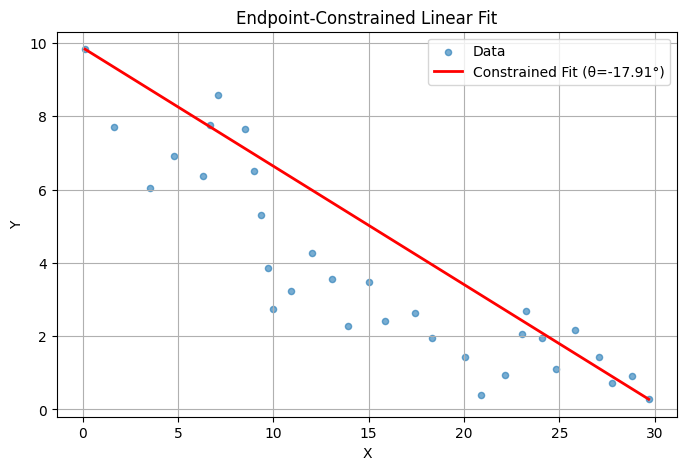

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================
# STEP 1: Load CSV
# ============================================

file_path = "D:/GitHubRepo/building_LLM_scratch/data.csv"   # <-- change path if needed
data = pd.read_csv(file_path)

# Extract x and y
x = data["x"].values
y = data["y"].values

# Ensure sorted by x (important!)
sort_idx = np.argsort(x)
x = x[sort_idx]
y = y[sort_idx]

# ============================================
# STEP 2: Constrained Fit (Touch Start & End)
# ============================================

x0, x1 = x[0], x[-1]
y0, y1 = y[0], y[-1]

# Force slope through endpoints
m_fit = (y1 - y0) / (x1 - x0)

# Compute intercept
b_fit = y0 - m_fit * x0

# Predicted values
y_fit = m_fit * x + b_fit

# ============================================
# STEP 3: Metrics
# ============================================

r2 = r2_score(y, y_fit)
rmse = np.sqrt(mean_squared_error(y, y_fit))
mae = mean_absolute_error(y, y_fit)

# Compute angle
angle = np.degrees(np.arctan(m_fit))

print("===== Constrained Fit Results =====")
print(f"Slope (m)   = {m_fit:.6f}")
print(f"Intercept   = {b_fit:.6f}")
print(f"Angle (deg) = {angle:.2f}")
print(f"R^2         = {r2:.6f}")
print(f"RMSE        = {rmse:.6f}")
print(f"MAE         = {mae:.6f}")

# ============================================
# STEP 4: Plot
# ============================================

plt.figure(figsize=(8,5))

plt.scatter(x, y, s=20, alpha=0.6, label="Data")
plt.plot(x, y_fit, 'r', linewidth=2,
         label=f"Constrained Fit (θ={angle:.2f}°)")

plt.title("Endpoint-Constrained Linear Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

plt.show()

Get some data:
1. 21 DH data
2. 52 WH data
3. 52 WH down (-25%) 
4. Trend fit, check angle ?. not how smooth data, no worry about R-2